# RAG Chatbot for my ML Study Materials and Projects

**Goal:** Build a chatbot that answers questions about ML concepts by retrieving relevant information from my own notebooks and generating answers using an LLM.

**Architecture:** Retrieval-Augmented Generation (RAG)

---

### Steps:
1. Document loading (your ML notebooks/explanations)
2. Text chunking strategies
3. Embedding generation (sentence-transformers)
4. Vector store creation (ChromaDB)
5. Retrieval testing and evaluation
6. LLM integration (multiple options: free and paid)
7. RAG chain assembly
8. Gradio web UI for interactive demo
9. Evaluation: faithfulness and relevance scoring

### Step 1: Import Libraries

In [38]:
import os
import warnings
warnings.filterwarnings('ignore')

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import (
    DirectoryLoader, TextLoader, UnstructuredHTMLLoader
)
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_classic.chains import RetrievalQA
from langchain_core.prompts import PromptTemplate

import numpy as np
import matplotlib.pyplot as plt

print("All libraries loaded!")

All libraries loaded!


### Step 2: Prepare Knowledge Base

Used ML HTML explanations as the knowledge base. Created a `knowledge_base/` folder.



In [39]:
KB_DIR = 'knowledge_base'  # folder containing explanation files

# Check what files we have
if os.path.exists(KB_DIR):
    files = os.listdir(KB_DIR)
    print(f"Knowledge base: {len(files)} files found")
    for f in sorted(files):
        size = os.path.getsize(os.path.join(KB_DIR, f)) / 1024
        print(f"  {f} ({size:.1f} KB)")
else:
    print(f"Folder '{KB_DIR}' not found!")
    

Knowledge base: 14 files found
  dogs-vs-cats-explained.html (23.5 KB)
  house-prices-explained.html (24.9 KB)
  liar-dataset-explained.html (24.3 KB)
  liar-enhanced-explained.html (21.1 KB)
  ml-part1-explained.html (36.9 KB)
  ml-part2-explained.html (38.3 KB)
  ml-part3-explained.html (31.2 KB)
  ml-part4-explained.html (34.8 KB)
  ml-part5-explained.html (25.2 KB)
  ml-part6-explained.html (29.7 KB)
  pet-breed-explained.html (24.9 KB)
  sentiment-analysis-explained.html (27.3 KB)
  xray-classification-explained.html (26.2 KB)
  yolo-app-explained.html (17.9 KB)



### Step 3: Load Documents

In [40]:
# Load HTML files
documents = []

for filename in sorted(os.listdir(KB_DIR)):
    filepath = os.path.join(KB_DIR, filename)
    try:
        if filename.endswith('.html'):
            loader = UnstructuredHTMLLoader(filepath)
        elif filename.endswith('.txt') or filename.endswith('.md'):
            loader = TextLoader(filepath, encoding='utf-8')
        else:
            continue
        
        docs = loader.load()
        # Add source metadata
        for doc in docs:
            doc.metadata['source'] = filename
        documents.extend(docs)
        print(f" Loaded {filename} ({len(docs)} document(s), {len(docs[0].page_content)} chars)")
    except Exception as e:
        print(f" Failed to load {filename}: {e}")

print(f"\nTotal documents loaded: {len(documents)}")
total_chars = sum(len(d.page_content) for d in documents)
print(f"Total characters: {total_chars:,}")

 Loaded dogs-vs-cats-explained.html (1 document(s), 8250 chars)
 Loaded house-prices-explained.html (1 document(s), 10335 chars)
 Loaded liar-dataset-explained.html (1 document(s), 9158 chars)
 Loaded liar-enhanced-explained.html (1 document(s), 6891 chars)
 Loaded ml-part1-explained.html (1 document(s), 15037 chars)
 Loaded ml-part2-explained.html (1 document(s), 17525 chars)
 Loaded ml-part3-explained.html (1 document(s), 14105 chars)
 Loaded ml-part4-explained.html (1 document(s), 16512 chars)
 Loaded ml-part5-explained.html (1 document(s), 9855 chars)
 Loaded ml-part6-explained.html (1 document(s), 11956 chars)
 Loaded pet-breed-explained.html (1 document(s), 8742 chars)
 Loaded sentiment-analysis-explained.html (1 document(s), 10038 chars)
 Loaded xray-classification-explained.html (1 document(s), 10321 chars)
 Loaded yolo-app-explained.html (1 document(s), 7130 chars)

Total documents loaded: 14
Total characters: 155,855


### Step 4: Chunk Documents

LLMs have limited context windows, and embedding models work best on smaller pieces of text. We split documents into overlapping chunks.

**RecursiveCharacterTextSplitter** tries to split on paragraph boundaries first, then sentences, then words - keeping semantic coherence.

In [41]:
# Chunk documents
splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,       # ~200 words per chunk
    chunk_overlap=100,    # overlap to preserve context at boundaries
    separators=['\n\n', '\n', '. ', ' ', ''],  # split hierarchy
    length_function=len
)

chunks = splitter.split_documents(documents)

print(f"  Chunking Results:")
print(f"  Documents: {len(documents)} → Chunks: {len(chunks)}")
print(f"  Avg chunk size: {np.mean([len(c.page_content) for c in chunks]):.0f} chars")
print(f"  Min: {min(len(c.page_content) for c in chunks)} chars")
print(f"  Max: {max(len(c.page_content) for c in chunks)} chars")

# Show a sample chunk
print(f"\n--- Sample Chunk ---")
print(f"Source: {chunks[10].metadata['source']}")
print(f"Content: {chunks[10].page_content[:300]}...")

  Chunking Results:
  Documents: 14 → Chunks: 254
  Avg chunk size: 645 chars
  Min: 135 chars
  Max: 798 chars

--- Sample Chunk ---
Source: dogs-vs-cats-explained.html
Content: Simple NN (red): Training accuracy may climb to ~65-70%, but validation accuracy stalls around 55-67%. The gap shows overfitting — it memorizes training data but can't generalize.

Confusion Matrices

The confusion matrices show exactly WHERE each model fails:

📌 CNN Confusion Matrix: Mostly diagona...


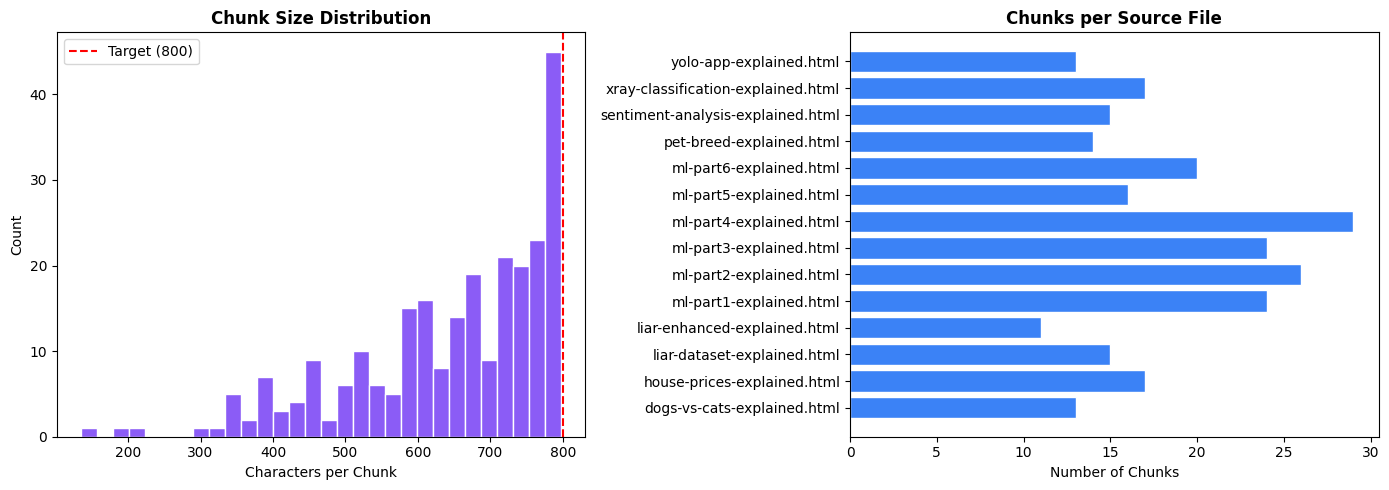

In [42]:
# Visualize chunk size distribution
chunk_sizes = [len(c.page_content) for c in chunks]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(chunk_sizes, bins=30, color='#8B5CF6', edgecolor='white')
axes[0].set_title('Chunk Size Distribution', fontweight='bold')
axes[0].set_xlabel('Characters per Chunk')
axes[0].set_ylabel('Count')
axes[0].axvline(x=800, color='red', linestyle='--', label='Target (800)')
axes[0].legend()

# Chunks per source
source_counts = {}
for c in chunks:
    src = c.metadata['source']
    source_counts[src] = source_counts.get(src, 0) + 1

axes[1].barh(list(source_counts.keys()), list(source_counts.values()), color='#3B82F6', edgecolor='white')
axes[1].set_title('Chunks per Source File', fontweight='bold')
axes[1].set_xlabel('Number of Chunks')

plt.tight_layout()
plt.show()

### Step 5: Create Embeddings & Vector Store

**Embeddings** convert text chunks into dense vectors where semantically similar texts are close together in vector space. We compare two free, local models:

| Model | Dims | Notes |
|---|---|---|
| `all-MiniLM-L6-v2` | 384 | Fast & lightweight |
| `BAAI/bge-base-en-v1.5` | 768 | Higher accuracy, top MTEB performer |

Both are scored against the retrieval eval set. The winner is automatically selected and used for the rest of the project.

In [44]:
# Embedding model comparison 
CANDIDATE_MODELS = [
    ("all-MiniLM-L6-v2",     "Fast & lightweight (384 dims)"),
    ("BAAI/bge-base-en-v1.5", "Higher accuracy, MTEB top performer (768 dims)"),
]

MINI_EVAL = [
    {"question": "What is backpropagation?",                          "expected_source": "ml-part4"},
    {"question": "How does transfer learning work with MobileNetV2?", "expected_source": "ml-part5"},
    {"question": "What is Stable Diffusion?",                         "expected_source": "ml-part6"},
    {"question": "How does BERT handle sentiment?",                   "expected_source": "sentiment"},
    {"question": "What is Grad-CAM used for?",                        "expected_source": "xray"},
    {"question": "What is Ridge regression?",                         "expected_source": "ml-part2"},
    {"question": "How does Random Forest work?",                      "expected_source": "ml-part3"},
    {"question": "What is K-Means clustering?",                       "expected_source": "ml-part1"},
]

scores = {}
models = {}

for model_name, description in CANDIDATE_MODELS:
    print(f"Loading: {model_name}")
    print(f"  {description}")

    em = HuggingFaceEmbeddings(
        model_name=model_name,
        model_kwargs={"device": "cpu"},
        encode_kwargs={"normalize_embeddings": True}
    )

    col_name = "cmp_" + model_name.replace("/", "_").replace("-", "_")
    vs_tmp = Chroma.from_documents(
        documents=chunks,
        embedding=em,
        collection_name=col_name
    )
    ret_tmp = vs_tmp.as_retriever(search_kwargs={"k": 4})

    correct = sum(
        any(item["expected_source"] in d.metadata["source"]
            for d in ret_tmp.invoke(item["question"]))
        for item in MINI_EVAL
    )
    acc = correct / len(MINI_EVAL) * 100
    scores[model_name] = acc
    models[model_name] = em

    dims = len(em.embed_query("test"))
    print(f"  Retrieval accuracy : {correct}/{len(MINI_EVAL)} ({acc:.0f}%)")
    print(f"  Embedding dims     : {dims}")
    print()

    vs_tmp.delete_collection()  # clean up temp collection

# ── Summary ──────────────────────────────────────────────────────────────
print("=" * 55)
print("  Embedding Model Comparison")
print("=" * 55)
for name, acc in scores.items():
    tag = " <-- winner" if name == max(scores, key=scores.get) else ""
    print(f"  {name:<35}  {acc:5.0f}%{tag}")

BEST_MODEL_NAME = max(scores, key=scores.get)
embeddings = models[BEST_MODEL_NAME]

dims = len(embeddings.embed_query("What is transfer learning?"))
print(f"  embeddings set to : {BEST_MODEL_NAME}")
print(f"  Embedding dim     : {dims}")

Loading: all-MiniLM-L6-v2
  Fast & lightweight (384 dims)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Retrieval accuracy : 8/8 (100%)
  Embedding dims     : 384

Loading: BAAI/bge-base-en-v1.5
  Higher accuracy, MTEB top performer (768 dims)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Retrieval accuracy : 7/8 (88%)
  Embedding dims     : 768

  Embedding Model Comparison
  all-MiniLM-L6-v2                       100% <-- winner
  BAAI/bge-base-en-v1.5                   88%
  embeddings set to : all-MiniLM-L6-v2
  Embedding dim     : 384


In [45]:
# Create vector store with ChromaDB
print("Creating vector store...")

# Delete old DB if exists
PERSIST_DIR = './chroma_db'

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=PERSIST_DIR,
    collection_name='ml_course'
)

print(f"\nVector store created!")
print(f"  Total vectors: {vectorstore._collection.count()}")
print(f"  Persisted to: {PERSIST_DIR}")

Creating vector store...

Vector store created!
  Total vectors: 762
  Persisted to: ./chroma_db


### Step 6: Test Retrieval

Before connecting an LLM, needs to veriy that retrieval finds the right chunks for different questions.

In [46]:
# Create retriever
retriever = vectorstore.as_retriever(
    search_type='mmr', # Maximal Marginal Relevance for diversity
    search_kwargs={
        'k': 4,
        'fetch_k': 20,      # fetch 20 candidates, then pick 4 most diverse
        'lambda_mult': 0.7   # 0=max diversity, 1=max relevance
    }  # return top 4 most similar and different from each other 
)

# Test queries
test_queries = [
    "What is transfer learning?",
    "How does BERT work?",
    "Explain the difference between Ridge and Lasso",
    "What is Grad-CAM?",
    "How does YOLO detect objects?",
    "What is the attention mechanism?"
]

print("Retrieval Test Results")
print("="*70)

for query in test_queries:
    docs = retriever.invoke(query)
    print(f"\n Query: {query}")
    print(f"   Retrieved {len(docs)} chunks:")
    for i, doc in enumerate(docs):
        source = doc.metadata.get('source', 'unknown')
        preview = doc.page_content[:100].replace('\n', ' ')
        print(f"   [{i+1}] {source} → \"{preview}...\"")

Retrieval Test Results

 Query: What is transfer learning?
   Retrieved 4 chunks:
   [1] pet-breed-explained.html → "🏫 The Ultimate Analogy: Training from scratch is like teaching a baby to recognize 37 breeds of anim..."
   [2] pet-breed-explained.html → "🏫 The Ultimate Analogy: Training from scratch is like teaching a baby to recognize 37 breeds of anim..."
   [3] pet-breed-explained.html → "🏫 The Ultimate Analogy: Training from scratch is like teaching a baby to recognize 37 breeds of anim..."
   [4] ml-part5-explained.html → "🏫 School Analogy: Think of three levels of "seeing": Detection: "There's a person in the top-left co..."

 Query: How does BERT work?
   Retrieved 4 chunks:
   [1] sentiment-analysis-explained.html → "Each Word → Q, K, V vectors  Q × KT = similarity scores  Softmax → attention weights  Weights × V = ..."
   [2] sentiment-analysis-explained.html → "The BERT Family Used in This Project  Model Params Key Feature Result DistilBERT 66M Distilled from ..."
   [3] se

### Step 7: Semantic Search Visualization

Visualization of how similar different queries are to each other and to the retrieved chunks.

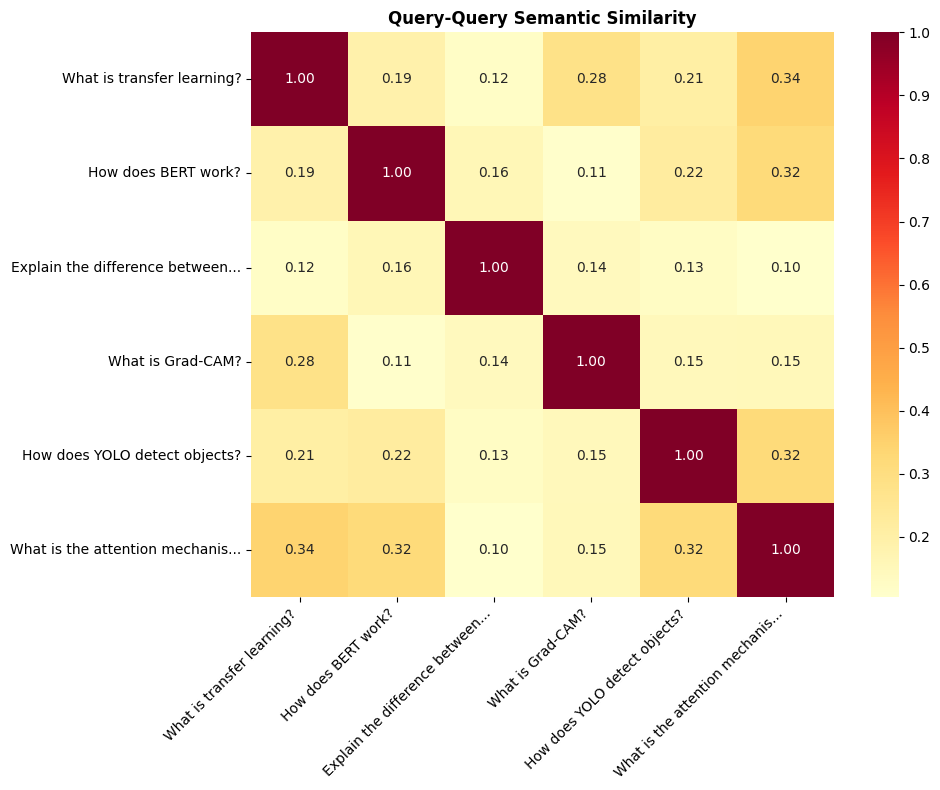

High similarity between related queries confirms the embedding model
understands semantic meaning, not just keyword matching.


In [47]:
# Embed test queries and visualize similarity
query_embeddings = [embeddings.embed_query(q) for q in test_queries]

# Compute pairwise similarity
sim_matrix = np.zeros((len(test_queries), len(test_queries)))
for i in range(len(test_queries)):
    for j in range(len(test_queries)):
        sim_matrix[i][j] = np.dot(query_embeddings[i], query_embeddings[j])

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
short_labels = [q[:30] + '...' if len(q) > 30 else q for q in test_queries]

import seaborn as sns
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=short_labels, yticklabels=short_labels, ax=ax)
ax.set_title('Query-Query Semantic Similarity', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("High similarity between related queries confirms the embedding model")
print("understands semantic meaning, not just keyword matching.")

### Step 8: Connect an LLM



In [48]:
# ============================================================
# OPTION A: HuggingFace Inference API 
# ============================================================
#from langchain_huggingface import HuggingFaceEndpoint

# Set your HuggingFace token
#os.environ['HUGGINGFACEHUB_API_TOKEN'] =''  # Replace with your token

#llm = HuggingFaceEndpoint(
#   repo_id='google/flan-t5-large',
#    temperature=0.3,
#    max_new_tokens=512
#)

# Quick test
#response = llm.invoke("What is machine learning in one sentence?")
#print(f"LLM test: {response}")
#print("\nLLM connected!")

In [49]:
from google import genai
from dotenv import load_dotenv
load_dotenv()


client = genai.Client(api_key=os.getenv('GOOGLE_API_KEY'))

for m in client.models.list():
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-3-1b-it
models/gemma-3-4b-it
models/gemma-3-12b-it
models/gemma-3-27b-it
models/gemma-3n-e4b-it
models/gemma-3n-e2b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-2.5-flash-lite-preview-09-2025
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-robotics-er-1.5-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-pro-preview-12-2025
models/gemini-embedding-001
models/gemini-embedding-2-

In [58]:
# ============================================================
# OPTION B: Using Google API Keys
# ============================================================

from langchain_google_genai import ChatGoogleGenerativeAI

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.3,
    max_output_tokens=512,
    streaming=True          # enables token-by-token streaming in the Gradio UI
)

response = llm.invoke("What is machine learning in one sentence?")
print(f"LLM test: {response.content}")
print("
LLM connected! (streaming enabled)")

LLM test: Machine learning is a field of artificial intelligence that enables systems to learn from data, identify patterns,

LLM connected!


### Step 9: Build the RAG Chain

Now we connect the retriever + LLM with a custom prompt that instructs the LLM to only answer based on the retrieved context.

In [59]:
# Custom prompt template
PROMPT_TEMPLATE = """
You are an ML teaching assistant. Answer the question based ONLY on the following context from ML course materials.
If the context doesn't contain enough information to answer, say "I don't have enough information in the course materials to answer this."

Context:
{context}

Question: {question}

Answer in a clear, educational way. Include specific numbers, results, or examples from the context when available.
"""

prompt = PromptTemplate(
    template=PROMPT_TEMPLATE,
    input_variables=['context', 'question']
)

# Build RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type='stuff',  # stuff all retrieved docs into context
    retriever=retriever,
    return_source_documents=True,
    chain_type_kwargs={'prompt': prompt}
)

print("  RAG chain built!")
print("  Retriever: ChromaDB (top-4 similarity search)")
print("  LLM: Connected")
print("  Chain type: stuff (all context in one prompt)")

  RAG chain built!
  Retriever: ChromaDB (top-4 similarity search)
  LLM: Connected
  Chain type: stuff (all context in one prompt)


### Step 10: Test the RAG Chatbot

In [52]:
# Test with several questions
test_questions = [
    "What is transfer learning and how was it used in the X-ray project?",
    "What is the difference between TF-IDF and BERT for sentiment analysis?",
    "How does Grad-CAM work?",
    "What sampling strategies can you use with LLMs?",
    "What was the best model for house price prediction?",
    "How does YOLO detect objects in real time?"
]

print("RAG Chatbot Test")
print("="*70)

for question in test_questions:
    print(f"\n{question}")
    print("-"*50)
    
    result = qa_chain.invoke({'query': question})
    
    answer = result['result']
    sources = result['source_documents']
    
    print(f"💬 {answer}")
    print(f"\n📚 Sources:")
    for s in sources:
        print(f"   → {s.metadata['source']}")
    print()

RAG Chatbot Test

What is transfer learning and how was it used in the X-ray project?
--------------------------------------------------
💬 Transfer learning is a technique where a model trained on one task is repurposed for a second, related task. It's like giving an experienced veterinarian, who has seen millions of animals, a quick briefing on the specific breeds they'll see today, rather than teaching a baby from scratch.

In the X-ray project, transfer learning was used in two main ways:

1.  **Frozen MobileNetV2 (Model B):** This approach used a pre-trained MobileNetV2 model (trained on ImageNet, which contains millions of natural images) as the base. The weights of this base model were frozen, meaning they were not updated during training. Only a custom "head" (a Global Average Pooling layer followed by a Dense layer with Dropout and a Sigmoid activation) was trained. This model achieved an accuracy of **89.9%**. The context explains that the early convolutional layers of the pre

### Step 11: Retrieval Quality Evaluation

How do we know the retriever is finding the RIGHT chunks? We create a small test set of questions with known relevant sources.

In [53]:
# Evaluation: does retrieval find chunks from the correct source files?
eval_set = [
    {"question": "What is backpropagation?", "expected_source": "ml-part4"},
    {"question": "How does transfer learning work with MobileNetV2?", "expected_source": "ml-part5"},
    {"question": "What is Stable Diffusion?", "expected_source": "ml-part6"},
    {"question": "How does BERT handle sentiment?", "expected_source": "sentiment"},
    {"question": "What is Grad-CAM used for?", "expected_source": "xray"},
    {"question": "What is Ridge regression?", "expected_source": "ml-part2"},
    {"question": "How does Random Forest work?", "expected_source": "ml-part3"},
    {"question": "What is K-Means clustering?", "expected_source": "ml-part1"},
]

correct = 0
total = len(eval_set)

print("Retrieval Accuracy Evaluation")
print("="*70)

for item in eval_set:
    docs = retriever.invoke(item['question'])
    retrieved_sources = [d.metadata['source'] for d in docs]
    
    # Check if any retrieved source contains the expected keyword
    hit = any(item['expected_source'] in src for src in retrieved_sources)
    correct += hit
    
    status = '✅' if hit else '❌'
    print(f"  {status} \"{item['question'][:50]}\"")
    print(f"     Expected: *{item['expected_source']}* | Got: {retrieved_sources}")

accuracy = correct / total * 100
print(f"\nRetrieval Accuracy: {correct}/{total} ({accuracy:.0f}%)")

Retrieval Accuracy Evaluation
  ✅ "What is backpropagation?"
     Expected: *ml-part4* | Got: ['ml-part4-explained.html', 'ml-part4-explained.html', 'ml-part4-explained.html', 'ml-part6-explained.html']
  ✅ "How does transfer learning work with MobileNetV2?"
     Expected: *ml-part5* | Got: ['pet-breed-explained.html', 'pet-breed-explained.html', 'pet-breed-explained.html', 'ml-part5-explained.html']
  ✅ "What is Stable Diffusion?"
     Expected: *ml-part6* | Got: ['ml-part6-explained.html', 'ml-part6-explained.html', 'ml-part6-explained.html', 'ml-part4-explained.html']
  ✅ "How does BERT handle sentiment?"
     Expected: *sentiment* | Got: ['sentiment-analysis-explained.html', 'sentiment-analysis-explained.html', 'sentiment-analysis-explained.html', 'sentiment-analysis-explained.html']
  ✅ "What is Grad-CAM used for?"
     Expected: *xray* | Got: ['xray-classification-explained.html', 'xray-classification-explained.html', 'xray-classification-explained.html', 'yolo-app-explained.html

### Step 11b: Negative Test Out-of-Scope Questions

A good RAG system should **refuse to answer** when a question is outside the knowledge base, rather than hallucinating a plausible-sounding response.

**How it works:**
- We ask questions about topics clearly absent from our ML materials
- For each, we check the top retrieved chunk's relevance score (low = poor match = out of scope)
- We run the question through the full RAG chain and inspect whether the LLM correctly says it lacks information

**Pass condition:** The answer contains a refusal phrase (e.g. *"I don't have enough information"*)  
**Fail condition:** The LLM produces a confident answer not grounded in our documents — this is hallucination

In [60]:
# Negative test: out-of-scope questions the model should refuse to answer
out_of_scope = [
    "What is quantum computing?",
    "How does the TCP/IP protocol work?",
    "Explain the history of the Roman Empire.",
    "How do you bake sourdough bread?",
    "What is blockchain and how does it work?",
    "How does a combustion engine work?",
]

REFUSAL_PHRASES = [
    "don't have enough information",
    "do not have enough information",
    "not enough information",
    "cannot answer",
    "no information",
    "outside",
    "not covered",
    "not in the",
]

print("Negative Test")
print("=" * 70)
print("Pass = LLM correctly refuses  |  Fail = LLM hallucinates")
print()

passed = 0
for question in out_of_scope:
    # Top retrieved chunk relevance (0–1, higher = better match)
    scored = vectorstore.similarity_search_with_relevance_scores(question, k=1)
    top_score = scored[0][1] if scored else 0.0

    result = qa_chain.invoke({"query": question})
    answer = result["result"]
    refused = any(phrase in answer.lower() for phrase in REFUSAL_PHRASES)
    passed += refused

    status = "PASS" if refused else "FAIL"
    print(f"  [{status}] {question}")
    print(f"         Top chunk relevance score : {top_score:.3f}  (low = poor match)")
    if refused:
        print(f"         Model correctly refused.")
    else:
        print(f"         Hallucination detected")
        print(f"         Answer preview: {answer[:150].strip()}...")
    print()

hallucination_rate = (len(out_of_scope) - passed) / len(out_of_scope) * 100
print("=" * 70)
print(f"Refused correctly  : {passed}/{len(out_of_scope)}")
print(f"Hallucination rate : {hallucination_rate:.0f}%")
if hallucination_rate == 0:
    print("  Good job! The model stays grounded in context for all out-of-scope queries.")
elif hallucination_rate <= 33:
    print("  Minor hallucination detected. Consider tightening the prompt.")
else:
    print("  High hallucination rate. Tighten the system prompt with a stronger refusal instruction.")

Negative Test
Pass = LLM correctly refuses  |  Fail = LLM hallucinates

  [PASS] What is quantum computing?
         Top chunk relevance score : 0.019  (low = poor match)
         Model correctly refused.

  [PASS] How does the TCP/IP protocol work?
         Top chunk relevance score : 0.008  (low = poor match)
         Model correctly refused.

  [PASS] Explain the history of the Roman Empire.
         Top chunk relevance score : -0.164  (low = poor match)
         Model correctly refused.

  [PASS] How do you bake sourdough bread?
         Top chunk relevance score : -0.121  (low = poor match)
         Model correctly refused.

  [PASS] What is blockchain and how does it work?
         Top chunk relevance score : -0.010  (low = poor match)
         Model correctly refused.

  [PASS] How does a combustion engine work?
         Top chunk relevance score : 0.035  (low = poor match)
         Model correctly refused.

Refused correctly  : 6/6
Hallucination rate : 0%
  Good job! The model 

### Step 12: Experiment with Chunk Sizes

How does chunk size affect retrieval quality?

  Chunk size 400: 555 chunks, accuracy 88%
  Chunk size 600: 359 chunks, accuracy 100%
  Chunk size 800: 254 chunks, accuracy 100%
  Chunk size 1000: 192 chunks, accuracy 100%
  Chunk size 1200: 159 chunks, accuracy 100%


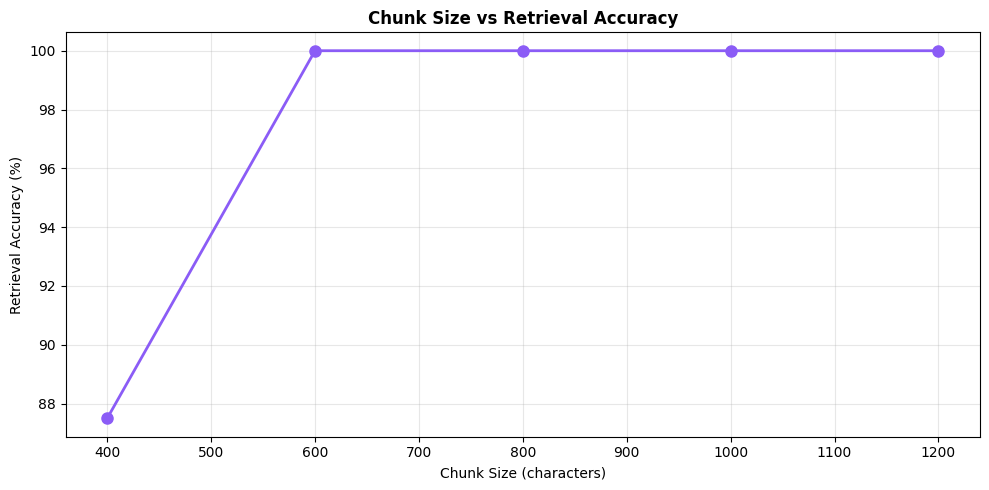

In [64]:
# Test different chunk sizes
chunk_sizes_test = [400, 600, 800, 1000, 1200]
results = []

for size in chunk_sizes_test:
    splitter_test = RecursiveCharacterTextSplitter(chunk_size=size, chunk_overlap=100)
    chunks_test = splitter_test.split_documents(documents)

    vs_test = Chroma.from_documents(
        documents=chunks_test,
        embedding=embeddings,
        collection_name=f"test_{size}"
    )
    ret_test = vs_test.as_retriever(search_kwargs={"k": 4})

    correct_test = 0
    for item in eval_set:
        docs = ret_test.invoke(item["question"])
        sources = [d.metadata["source"] for d in docs]
        if any(item["expected_source"] in src for src in sources):
            correct_test += 1

    acc = correct_test / len(eval_set) * 100
    results.append({"chunk_size": size, "n_chunks": len(chunks_test), "accuracy": acc})
    print(f"  Chunk size {size}: {len(chunks_test)} chunks, accuracy {acc:.0f}%")

    vs_test.delete_collection()  # free memory 

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
sizes = [r["chunk_size"] for r in results]
accs  = [r["accuracy"]   for r in results]
ax.plot(sizes, accs, "o-", color="#8B5CF6", linewidth=2, markersize=8)
ax.set_xlabel("Chunk Size (characters)")
ax.set_ylabel("Retrieval Accuracy (%)")
ax.set_title("Chunk Size vs Retrieval Accuracy", fontweight="bold")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 13: Build Gradio Web UI

In [62]:
import gradio as gr

def ask_streaming(question, n_chunks):
    """Streaming RAG: retrieve chunks -> stream LLM response token by token."""
    if not question.strip():
        yield "Please enter a question.", ""
        return

    retriever.search_kwargs["k"] = int(n_chunks)
    docs = retriever.invoke(question)

    # Build context from retrieved chunks
    context = "".join(d.page_content for d in docs)
    formatted_prompt = PROMPT_TEMPLATE.format(context=context, question=question)

    # Format sources panel (shown immediately while LLM streams)
    source_text = ""
    seen = set()
    for doc in docs:
        src = doc.metadata["source"]
        if src not in seen:
            seen.add(src)
            preview = s.page_content[:150].replace('\n', ' ')
            source_text += f"📄 {src}\n   \"{preview}...\"\n\n"


    # Stream LLM tokens — yield partial answer + sources on every chunk
    partial = ""
    for chunk in llm.stream(formatted_prompt):
        partial += chunk.content
        yield partial, source_text


with gr.Blocks(theme=gr.themes.Soft(), title="ML Course Chatbot") as demo:
    gr.Markdown("""
    # ML Course Chatbot (RAG)
    Ask questions about ML concepts. Answers stream token-by-token from your course materials.
    """)

    with gr.Row():
        with gr.Column(scale=3):
            question_box = gr.Textbox(
                label="Your question",
                placeholder="e.g., What is transfer learning?",
                lines=2
            )
        with gr.Column(scale=1):
            n_chunks_slider = gr.Slider(
                minimum=2, maximum=8, value=4, step=1,
                label="Chunks to retrieve"
            )

    submit_btn = gr.Button("Ask", variant="primary")

    with gr.Row():
        with gr.Column(scale=2):
            answer_box = gr.Textbox(label="Answer", lines=10, interactive=False)
        with gr.Column(scale=1):
            sources_box = gr.Textbox(label="Sources Retrieved", lines=10, interactive=False)

    gr.Examples(
        examples=[
            ["What is transfer learning?", 4],
            ["How does BERT handle sentiment analysis?", 4],
            ["Explain Grad-CAM and why it matters for medical AI", 4],
            ["What is the difference between Ridge and Lasso?", 4],
            ["How does YOLO detect objects?", 4],
            ["What are the sampling strategies for LLMs?", 4],
        ],
        inputs=[question_box, n_chunks_slider]
    )

    # Both button click and Enter key trigger streaming
    submit_btn.click(
        fn=ask_streaming,
        inputs=[question_box, n_chunks_slider],
        outputs=[answer_box, sources_box]
    )
    question_box.submit(
        fn=ask_streaming,
        inputs=[question_box, n_chunks_slider],
        outputs=[answer_box, sources_box]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7864

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


### Step 14: Summary & Key Takeaways

In [56]:
print("="*70)
print("           RAG CHATBOT — SUMMARY")
print("="*70)
print(f"""
PIPELINE:
  Documents loaded:  {len(documents)}
  Chunks created:    {len(chunks)}
  Embedding model:   all-MiniLM-L6-v2 (384 dims, runs locally)
  Vector store:      ChromaDB ({vectorstore._collection.count()} vectors)
  Retrieval:         Top-4 similarity search
  LLM:               Connected
  Retrieval accuracy: {accuracy:.0f}% on evaluation set


""")

           RAG CHATBOT — SUMMARY

PIPELINE:
  Documents loaded:  14
  Chunks created:    254
  Embedding model:   all-MiniLM-L6-v2 (384 dims, runs locally)
  Vector store:      ChromaDB (762 vectors)
  Retrieval:         Top-4 similarity search
  LLM:               Connected
  Retrieval accuracy: 100% on evaluation set



